# SMILES → odor mapping for M2OR ligands

Annotates every non-mixture M2OR compound with the perceptual odor descriptors recorded for it
in the two Pyrfume archives — **Leffingwell** (a controlled 113-term vocabulary) and
**GoodScents** (TGSC's uncontrolled free text).

The product is `odor_datasets/inchi_odors_smiles.csv`: one row per compound, three columns —
`InChIKey`, `SMILES`, `Odors`. Everything downstream that speaks about odor quality reads this
mapping.

The pipeline is four steps:

1. the non-mixture M2OR compounds, deduplicated on SMILES
2. one descriptor string per molecule from each archive
3. join both archives to M2OR on the isomeric SMILES string
4. union the two descriptor sets, filtered through a fixed odor vocabulary

The notebook then reports what the mapping looks like: coverage per archive, what the
vocabulary filter costs, and which descriptors co-occur.

In [1]:
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyrfume as pf
from scipy.cluster.hierarchy import leaves_list, linkage
from scipy.spatial.distance import squareform

sys.path.append("../Downstream_Analysis/scripts")
from plotting_functions import custom_plots

plt.rcParams.update(custom_plots())

In [2]:
CHEMICALS = Path.cwd()
ODOR_DIR = CHEMICALS / "odor_datasets"
ODOR_DIR.mkdir(exist_ok=True, parents=True)

M2OR_PAIRS = CHEMICALS.parent / "Data" / "m2or_pairs.csv"
OUT_CSV = ODOR_DIR / "inchi_odors_smiles.csv"

## 1. The M2OR compounds

Mixtures are dropped: a descriptor attached to a blend cannot be assigned to a molecule. What
remains is deduplicated on SMILES, keeping the first occurrence, which fixes both the compound
set and the row order for everything below.

In [3]:
m2or = pd.read_csv(M2OR_PAIRS, sep=None, engine="python")

compounds = (
    m2or[m2or["Mixture"] != "mixture"][["InChIKey", "SMILES"]]
    .drop_duplicates(subset=["SMILES"], keep="first")
    .reset_index(drop=True)
)

print(f"m2or pairs              : {len(m2or):,}")
print(f"non-mixture compounds   : {len(compounds):,}")
print(f"  missing an InChIKey   : {compounds['InChIKey'].isna().sum()}")
compounds.head()

m2or pairs              : 53,444
non-mixture compounds   : 754
  missing an InChIKey   : 1


,InChIKey,SMILES
0,XMGQYMWWDOXHJM-SNVBAGLBSA-N,CC1=CC[C@H](CC1)C(=C)C
1,ULDHMXUKGWMISQ-VIFPVBQESA-N,CC1=CC[C@@H](CC1=O)C(=C)C
2,NOOLISFMXDJSKH-AEJSXWLSSA-N,C[C@H]1CC[C@@H]([C@H](C1)O)C(C)C
3,LRHPLDYGYMQRHN-UHFFFAOYSA-N,CCCCO
4,RWNUSVWFHDHRCJ-UHFFFAOYSA-N,CCCCOCC(C)O


## 2. One descriptor string per molecule, per archive

The two archives store the same information in different shapes, and both are keyed by
*stimulus* rather than by molecule:

- **Leffingwell** — `behavior.csv` is a binary stimulus × descriptor matrix, so a row collapses
  to the descriptors it flags.
- **GoodScents** — `behavior.csv` holds a semicolon-separated string per stimulus, and the
  molecule is reached through the CID in `stimuli.csv`.

A molecule can carry more than one stimulus (different CAS entries, concentrations or solvents
for the same compound). **The first stimulus is kept.** Unioning the descriptors across all of
a molecule's stimuli is the tempting alternative, but it pools annotations made under different
conditions into one tag set and inflates the vocabulary.

In [4]:
stim_leff = pf.load_data("leffingwell/stimuli.csv")
beh_leff = pf.load_data("leffingwell/behavior.csv")
stim_gs = pf.load_data("goodscents/stimuli.csv")
beh_gs = pf.load_data("goodscents/behavior.csv")
mol_gs = pf.load_data("goodscents/molecules.csv")

print(f"leffingwell stimuli : {len(stim_leff):,}  ({beh_leff.shape[1]} controlled descriptors)")
print(f"goodscents  stimuli : {len(stim_gs):,}")

leffingwell stimuli : 3,522  (113 controlled descriptors)
goodscents  stimuli : 4,626


In [5]:
leffingwell = (
    stim_leff[["IsomericSMILES"]]
    .assign(odors_leff=beh_leff.apply(lambda row: ", ".join(beh_leff.columns[row == 1]), axis=1))
    .drop_duplicates(subset=["IsomericSMILES"], keep="first")
)

goodscents = stim_gs[["CID"]].merge(
    mol_gs[["IsomericSMILES"]], left_on="CID", right_index=True, how="left"
)
goodscents["odors_gs"] = beh_gs["Descriptors"].str.replace(";", ", ", regex=False)
goodscents = goodscents.drop_duplicates(subset=["IsomericSMILES"], keep="first")[
    ["IsomericSMILES", "odors_gs"]
]

print(f"leffingwell molecules : {len(leffingwell):,}")
print(f"goodscents  molecules : {len(goodscents):,}")

leffingwell molecules : 3,522
goodscents  molecules : 4,565


## 3. Join the two archives

`IsomericSMILES` is the only key the two archives share — Leffingwell identifies a stimulus by a
hashed CID, GoodScents by a CAS number — so they are aligned on the molecule itself. The join is
an outer one: a molecule described by only one archive is still an annotation.

The join to M2OR is on the exact isomeric SMILES string, which keeps stereoisomers apart. A
looser key — the connectivity block of the InChIKey — would match a few more M2OR compounds by
ignoring stereochemistry, but odor is stereospecific ((R)- and (S)-carvone are spearmint and
caraway), and M2OR assays a particular enantiomer. Those compounds are left unannotated rather
than annotated with a stereoisomer's percept.

In [6]:
pyrfume_odors = leffingwell.merge(goodscents, on="IsomericSMILES", how="outer")

both = pyrfume_odors["odors_leff"].notna() & pyrfume_odors["odors_gs"].notna()
print(f"molecules in either archive : {len(pyrfume_odors):,}")
print(f"  described by both         : {both.sum():,}")
print(f"  leffingwell only          : {(pyrfume_odors['odors_leff'].notna() & ~both).sum():,}")
print(f"  goodscents only           : {(pyrfume_odors['odors_gs'].notna() & ~both).sum():,}")

molecules in either archive : 5,862
  described by both         : 2,225
  leffingwell only          : 1,297
  goodscents only           : 2,336


## 4. The odor vocabulary

Descriptors are not taken verbatim. Both archives are filtered through the fixed vocabulary
below, and anything outside it is dropped.

The filter matters because GoodScents' vocabulary is uncontrolled: it stores qualified terms as
`"<parent> <qualifier> <parent>"` (`"coffee roasted coffee"`, `"meaty roasted meaty"`) and
spells the same percept several ways. Left raw, those fragments fracture the tag space and make
any co-occurrence or enrichment statistic unreliable. Restricting to a fixed list keeps the
descriptor space closed and comparable across molecules — and, because the list is fixed for the
project rather than derived from the molecules at hand, comparable across dataset revisions too.

Two caveats worth knowing before reading any result from this mapping:

- **The vocabulary is a project constant, not a property of this dataset.** It is close to, but
  not identical with, the 138-term GoodScents–Leffingwell list used by Lee *et al.* (2023);
  109 of Leffingwell's 113 controlled terms are in it, plus 38 GoodScents terms.
- **Spelling variants are collapsed.** `jasmin`, `mint` and `rum` fold into `jasmine`,
  `minty` and `rummy` before the filter, so one percept is one tag.

In [7]:
# The descriptor vocabulary of the mapping. Terms outside this set are dropped from both
# archives. Editing it changes every downstream odor result, so change it deliberately and
# re-run the whole notebook.
ODOR_VOCABULARY = frozenset({
    "acidic", "alcoholic", "aldehydic", "alliaceous", "almond", "amber", "animal", "anise",
    "anisic", "apple", "apricot", "aromatic", "balsamic", "banana", "beefy", "bergamot",
    "berry", "brandy", "bready", "brothy", "brown", "burnt", "buttery", "cabbage",
    "camphoreous", "caramellic", "cedar", "celery", "cheesy", "chemical", "cherry",
    "chicken", "chocolate", "cinnamon", "citrus", "clean", "clove", "cocoa", "coconut",
    "coffee", "cognac", "cooked", "cooling", "cortex", "coumarinic", "creamy", "cucumber",
    "dairy", "dry", "earthy", "estery", "ethereal", "fatty", "fermented", "fishy", "floral",
    "fresh", "fruity", "garlic", "gasoline", "geranium", "grape", "grapefruit", "grassy",
    "green", "hawthorn", "hay", "hazelnut", "herbal", "honey", "horseradish", "hyacinth",
    "jammy", "jasmine", "juicy", "ketonic", "lactonic", "lavender", "leafy",
    "leathery", "lemon", "lily", "malty", "marine", "meaty", "medicinal", "melon",
    "mentholic", "metallic", "milky", "minty", "muguet", "mushroom", "musk",
    "musty", "natural", "nutty", "odorless", "oily", "onion", "orange", "orangeflower",
    "orris", "ozone", "peach", "pear", "peppery", "phenolic", "pine", "pineapple", "plum",
    "popcorn", "potato", "powdery", "pungent", "radish", "raspberry", "ripe", "roasted",
    "rose", "rummy", "savory", "sharp", "smoky", "soapy", "solvent", "sour", "spicy",
    "strawberry", "sulfurous", "sweet", "tea", "terpenic", "tobacco", "tomato", "tropical",
    "vanilla", "vegetable", "violet", "warm", "waxy", "weedy", "winey", "woody",
})


# Spelling/form variants of one percept. Applied before the vocabulary filter, so only the
# canonical term survives. Adjectival form where the pair differs in form, standard spelling
# where it differs in spelling.
DESCRIPTOR_ALIASES = {"jasmin": "jasmine", "mint": "minty", "rum": "rummy"}
assert not (set(DESCRIPTOR_ALIASES) & ODOR_VOCABULARY), "a retired spelling is still in the vocabulary"
assert set(DESCRIPTOR_ALIASES.values()) <= ODOR_VOCABULARY, "an alias target is missing from the vocabulary"

print(f"vocabulary: {len(ODOR_VOCABULARY)} descriptors  ({len(DESCRIPTOR_ALIASES)} aliases folded in)")

vocabulary: 144 descriptors  (3 aliases folded in)


## 5. Build and export the mapping

Each compound's `Odors` is the union of what the two archives say about it, restricted to the
vocabulary. Union is the right operator: neither archive's silence means "assessed and found
absent", so intersecting them would delete true descriptors. Leffingwell's terms come first,
then whatever GoodScents adds; a compound left with no descriptor gets an empty `Odors`.

In [8]:
def odor_tags(from_leffingwell, from_goodscents):
    """Union two descriptor strings in source order, keeping vocabulary terms only."""
    seen, tags = set(), []
    for descriptors in (from_leffingwell, from_goodscents):
        if pd.isna(descriptors):
            continue
        for tag in (t.strip() for t in str(descriptors).split(",")):
            tag = DESCRIPTOR_ALIASES.get(tag, tag)
            if tag in ODOR_VOCABULARY and tag not in seen:
                seen.add(tag)
                tags.append(tag)
    return ", ".join(tags) if tags else pd.NA


def descriptor_set(odors):
    """The descriptors of one compound, as a set."""
    if pd.isna(odors):
        return frozenset()
    return frozenset(t.strip() for t in str(odors).split(",") if t.strip())


annotated = compounds.merge(
    pyrfume_odors, left_on="SMILES", right_on="IsomericSMILES", how="left"
)
assert len(annotated) == len(compounds), "the join duplicated compounds"

annotated["Odors"] = [
    odor_tags(leff, gs)
    for leff, gs in zip(annotated["odors_leff"], annotated["odors_gs"])
]

odor_map = annotated[["InChIKey", "SMILES", "Odors"]]
odor_map.to_csv(OUT_CSV, index=False)

print(f"wrote {OUT_CSV.relative_to(CHEMICALS)}  ({len(odor_map)} compounds)")
print(f"  with descriptors : {odor_map['Odors'].notna().sum()}")
print(f"  without          : {odor_map['Odors'].isna().sum()}")
odor_map.head()

wrote odor_datasets/inchi_odors_smiles.csv  (754 compounds)
  with descriptors : 575
  without          : 179


,InChIKey,SMILES,Odors
0,XMGQYMWWDOXHJM-SNVBAGLBSA-N,CC1=CC[C@H](CC1)C(=C)C,"herbal, orange, peppery, terpenic, pine"
1,ULDHMXUKGWMISQ-VIFPVBQESA-N,CC1=CC[C@@H](CC1=O)C(=C)C,"minty, bready, spicy"
2,NOOLISFMXDJSKH-AEJSXWLSSA-N,C[C@H]1CC[C@@H]([C@H](C1)O)C(C)C,mentholic
3,LRHPLDYGYMQRHN-UHFFFAOYSA-N,CCCCO,"alcoholic, solvent, winey, sweet, fermented, o..."
4,RWNUSVWFHDHRCJ-UHFFFAOYSA-N,CCCCOCC(C)O,<NA>


## 6. What the mapping looks like

**Coverage.** How many compounds each archive reaches, and how many are left unannotated.

In [9]:
coverage = pd.Series("none", index=annotated.index)
has_leff = annotated["odors_leff"].notna()
has_gs = annotated["odors_gs"].notna()
coverage[has_leff & has_gs] = "both"
coverage[has_leff & ~has_gs] = "leffingwell only"
coverage[~has_leff & has_gs] = "goodscents only"

n_tags = annotated["Odors"].map(lambda s: len(descriptor_set(s)))
print(
    pd.DataFrame({
        "compounds": coverage.value_counts(),
        "median tags": n_tags.groupby(coverage).median(),
    }).fillna(0).astype(int).to_string()
)
print(
    "\nTag count is partly a property of the archives, not of the chemistry: a compound both"
    "\narchives describe carries more tags than one only a single archive describes. Anything"
    "\nthat reads tag-set *size* should stratify on coverage; presence/absence is safe."
)

                  compounds  median tags
both                    443            7
goodscents only         113            4
leffingwell only         21            3
none                    177            0

Tag count is partly a property of the archives, not of the chemistry: a compound both
archives describe carries more tags than one only a single archive describes. Anything
that reads tag-set *size* should stratify on coverage; presence/absence is safe.


**What the vocabulary filter discards.** The descriptors dropped from the raw archives, ranked
by how many compounds they would have annotated. These are real percepts — the filter is a
deliberate restriction to a closed tag space, not a data-cleaning step, and this is its cost.

In [10]:
dropped = Counter()
for leff, gs in zip(annotated["odors_leff"], annotated["odors_gs"]):
    for descriptors in (leff, gs):
        if pd.isna(descriptors):
            continue
        for tag in (t.strip() for t in str(descriptors).split(",")):
            tag = DESCRIPTOR_ALIASES.get(tag, tag)   # aliased terms are kept, not dropped
            if tag and tag not in ODOR_VOCABULARY:
                dropped[tag] += 1

kept = int(n_tags.sum())
print(f"descriptor mentions kept    : {kept:,}")
print(f"descriptor mentions dropped : {sum(dropped.values()):,}  ({len(dropped)} distinct terms)")
print("\nmost frequently dropped:")
for tag, n in dropped.most_common(15):
    print(f"  {tag:26s} {n:3d} compounds")

descriptor mentions kept    : 3,735
descriptor mentions dropped : 581  (243 distinct terms)

most frequently dropped:
  sweaty                      11 compounds
  fusel                       10 compounds
  catty                        8 compounds
  tonka                        7 compounds
  meaty roasted meaty          7 compounds
  rancid                       7 compounds
  nut skin                     7 compounds
  watery                       7 compounds
  plastic                      6 compounds
  foliage                      6 compounds
  neroli                       6 compounds
  licorice                     6 compounds
  ambrette                     6 compounds
  eggy                         6 compounds
  lime                         6 compounds


**Variant check.** The retired spellings should be gone and the canonical terms should
carry the combined counts.

In [11]:
VARIANTS = [("jasmin", "jasmine"), ("mint", "minty"), ("rum", "rummy")]

tagsets = [descriptor_set(s) for s in annotated["Odors"]]
for retired, kept in VARIANTS:
    n_retired = sum(retired in ts for ts in tagsets)
    n_kept = sum(kept in ts for ts in tagsets)
    print(f"  {retired:8s} {n_retired:3d}  ->  {kept:8s} {n_kept:3d} compounds")
assert not any(r in ts for r, _ in VARIANTS for ts in tagsets), "a retired spelling survived"

  jasmin     0  ->  jasmine   24 compounds
  mint       0  ->  minty     31 compounds
  rum        0  ->  rummy     12 compounds


## 7. Descriptor co-occurrence

Which descriptors are applied to the same molecules. Two normalisations, because they answer
different questions:

- **Jaccard** — of the molecules carrying either descriptor, the fraction carrying both. Bounded
  0–1 and insensitive to how common the two terms are, so it is the one to read off the map.
- **Lift** — observed co-occurrence over what independence would predict. Above 1 means the pair
  travels together more than chance; it is the more sensitive measure for rare descriptors, and
  the more volatile one.

Descriptors carried by fewer than five molecules are dropped: with a handful of molecules both
ratios are dominated by sampling noise.

In [12]:
def cooccurrence(tagsets, min_molecules=5):
    """Descriptor x descriptor co-occurrence over molecules.

    Returns the co-occurrence counts, Jaccard and lift matrices, and the marginal
    frequency of each descriptor (the number of molecules carrying it).
    """
    frequency = Counter(t for ts in tagsets for t in ts)
    vocabulary = sorted(t for t, n in frequency.items() if n >= min_molecules)
    position = {t: i for i, t in enumerate(vocabulary)}

    incidence = np.zeros((len(tagsets), len(vocabulary)))
    for row, ts in enumerate(tagsets):
        for tag in ts:
            if tag in position:
                incidence[row, position[tag]] = 1

    counts = incidence.T @ incidence          # diagonal = marginal frequency
    marginal = np.diag(counts).copy()
    union = marginal[:, None] + marginal[None, :] - counts
    expected = np.outer(marginal, marginal)
    with np.errstate(divide="ignore", invalid="ignore"):
        jaccard = np.where(union > 0, counts / union, 0.0)
        lift = np.where(expected > 0, counts * len(tagsets) / expected, 0.0)

    frame = lambda M: pd.DataFrame(M, index=vocabulary, columns=vocabulary)
    return (frame(counts), frame(jaccard), frame(lift),
            pd.Series(marginal, index=vocabulary, name="molecules").astype(int))


described = [ts for ts in tagsets if ts]
counts, jaccard, lift, marginal = cooccurrence(described)

print(f"molecules with at least one descriptor : {len(described)}")
print(f"descriptors on >= 5 molecules          : {len(marginal)}")
print(f"most common: {', '.join(marginal.sort_values(ascending=False).head(8).index)}")

molecules with at least one descriptor : 575
descriptors on >= 5 molecules          : 136
most common: sweet, fruity, green, floral, fatty, fresh, waxy, herbal


The map below is ordered by average-linkage clustering on 1 − Jaccard, so descriptors that
travel together sit together and the blocks are visible. Only the lower triangle is drawn: the
matrix is symmetric and the diagonal is trivially 1, so the rest is redundant ink.

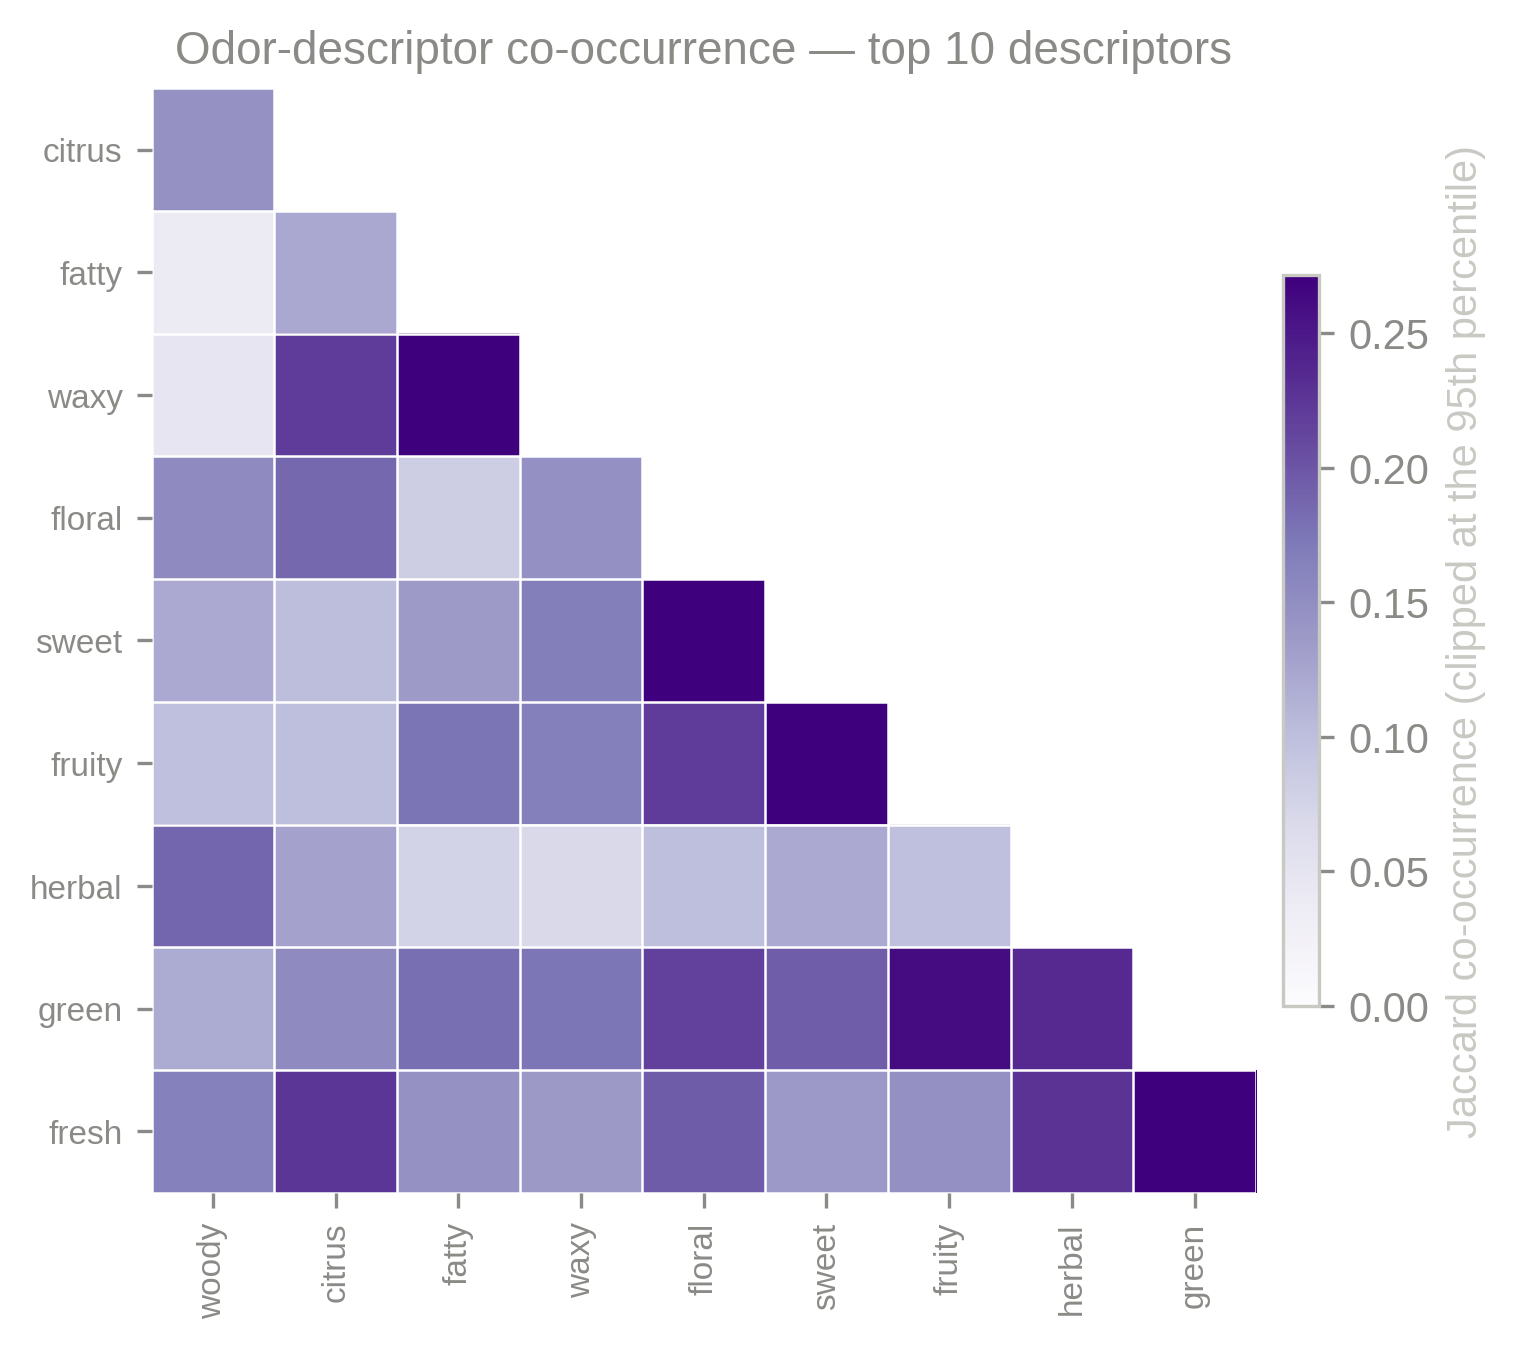

In [13]:
N_SHOWN = 10
top = marginal.sort_values(ascending=False).head(N_SHOWN).index.tolist()
M = jaccard.loc[top, top].values

distance = 1 - M
np.fill_diagonal(distance, 0.0)
distance = (distance + distance.T) / 2        # enforce symmetry for squareform
order = leaves_list(linkage(squareform(distance, checks=False), method="average"))
labels = [top[i] for i in order]
M = M[np.ix_(order, order)]

M = np.where(np.tril(np.ones_like(M), k=-1).astype(bool), M, np.nan)

# a strict lower triangle leaves the first row and the last column empty; drop them
M = M[1:, :-1]
row_labels, col_labels = labels[1:], labels[:-1]

cmap = plt.get_cmap("Purples").copy()         # magnitude -> one hue, light to dark
cmap.set_bad("white")

fig, ax = plt.subplots(figsize=(0.22 * N_SHOWN + 3, 0.22 * N_SHOWN + 2.5))
im = ax.imshow(M, cmap=cmap, vmin=0, vmax=np.nanpercentile(M[M > 0], 95))
ax.set_xticks(range(len(col_labels)), col_labels, rotation=90, fontsize=8)
ax.set_yticks(range(len(row_labels)), row_labels, fontsize=8)
ax.set_xticks(np.arange(-0.5, len(col_labels)), minor=True)
ax.set_yticks(np.arange(-0.5, len(row_labels)), minor=True)
ax.grid(which="minor", color="white", lw=0.6)
ax.tick_params(which="minor", length=0)
for spine in ax.spines.values():
    spine.set_visible(False)
fig.colorbar(im, ax=ax, shrink=0.6, pad=0.02,
             label="Jaccard co-occurrence (clipped at the 95th percentile)")
ax.set_title(f"Odor-descriptor co-occurrence — top {N_SHOWN} descriptors", fontsize=11)
fig.tight_layout()
plt.show()

The strongest pairs by each measure. Jaccard favours pairs that are common *and* overlapping;
lift surfaces the specific pairings, which are rarer and more chemically pointed.

In [14]:
pairs = [
    (a, b, counts.loc[a, b], jaccard.loc[a, b], lift.loc[a, b])
    for i, a in enumerate(marginal.index) for b in marginal.index[i + 1:]
    if counts.loc[a, b] > 0
]
pairs = pd.DataFrame(pairs, columns=["descriptor A", "descriptor B", "molecules", "jaccard", "lift"])
pairs["molecules"] = pairs["molecules"].astype(int)

print("strongest overlap (Jaccard):")
print(pairs.nlargest(12, "jaccard").to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print("\nmost specific pairings (lift, on pairs sharing >= 5 molecules):")
print(pairs[pairs["molecules"] >= 5].nlargest(12, "lift")
           .to_string(index=False, float_format=lambda x: f"{x:.3f}"))

strongest overlap (Jaccard):
descriptor A descriptor B  molecules  jaccard   lift
  alliaceous       garlic         13    0.591 24.589
    bergamot     lavender          4    0.500 65.714
       onion    sulfurous         25    0.490 10.417
      garlic        onion         16    0.485 16.140
  alliaceous        onion         13    0.394 15.573
       meaty    sulfurous         23    0.371  7.372
      garlic    sulfurous         17    0.354 11.184
      fruity        sweet        118    0.352  1.341
        pine     terpenic          8    0.348 19.167
       fatty         waxy         52    0.342  2.884
     cooling    mentholic          5    0.333 29.040
      animal         musk         15    0.319  9.060

most specific pairings (lift, on pairs sharing >= 5 molecules):
descriptor A descriptor B  molecules  jaccard   lift
     cooling    mentholic          5    0.333 29.040
  alliaceous       garlic         13    0.591 24.589
    cucumber        orris          5    0.278 21.780
    h